In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "m5-forecasting-accuracy"

calendar     = pd.read_csv(f"{DATA_DIR}/calendar.csv")
sell_prices  = pd.read_csv(f"{DATA_DIR}/sell_prices.csv")
sales_train  = pd.read_csv(f"{DATA_DIR}/sales_train_evaluation.csv")
sample_sub   = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

In [2]:
for name, df in [("sales_train", sales_train), ("calendar", calendar), 
                 ("sell_prices", sell_prices), ("sample_sub", sample_sub)]:
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(df.head(2))
    print()

=== sales_train ===
Shape: (30490, 1947)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  d_1935  d_1936  \
0       CA    0    0    0    0  ...       2       4       0       0       0   
1       CA    0    0    0    0  ...       0       1       2       1       1   

   d_1937  d_1938  d_1939  d_1940  d_1941  
0       0       3       3       0       1  
1       0       0       0       0       0  

[2 rows x 1947 columns]

=== calendar ===
Shape: (1969, 14)
         date  wm_yr_wk   weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101  Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101    Sunday     2      1  2011  d_2          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap

In [3]:
# Временной горизонт
d_cols = [c for c in sales_train.columns if c.startswith("d_")]
print(f"Дней в истории: {len(d_cols)}  ({d_cols[0]} — {d_cols[-1]})")
print(f"Период: {calendar['date'].min()} — {calendar['date'].max()}")
print()

# Иерархия датасета
for col in ["state_id", "store_id", "cat_id", "dept_id", "item_id"]:
    print(f"{col}: {sales_train[col].nunique()} уникальных")
print()
print(f"Всего рядов (SKU × store): {len(sales_train)}")

Дней в истории: 1941  (d_1 — d_1941)
Период: 2011-01-29 — 2016-06-19

state_id: 3 уникальных
store_id: 10 уникальных
cat_id: 3 уникальных
dept_id: 7 уникальных
item_id: 3049 уникальных

Всего рядов (SKU × store): 30490


In [4]:
sales_vals = sales_train[d_cols].values

# Доля нулевых продаж
zero_frac = (sales_vals == 0).mean()
print(f"Доля нулей во всей матрице продаж: {zero_frac:.1%}")

# Распределение нулей по SKU
zeros_per_sku = (sales_train[d_cols] == 0).mean(axis=1)
print(f"\nДоля нулевых дней по SKU:")
print(zeros_per_sku.describe().round(3))

# SKU с >90% нулей — кандидаты на intermittent demand
intermittent = (zeros_per_sku > 0.9).sum()
print(f"\nSKU с >90% нулевых дней: {intermittent} ({intermittent/len(sales_train):.1%})")

Доля нулей во всей матрице продаж: 68.0%

Доля нулевых дней по SKU:
count    30490.000
mean         0.680
std          0.223
min          0.002
25%          0.535
50%          0.733
75%          0.865
max          0.994
dtype: float64

SKU с >90% нулевых дней: 5133 (16.8%)


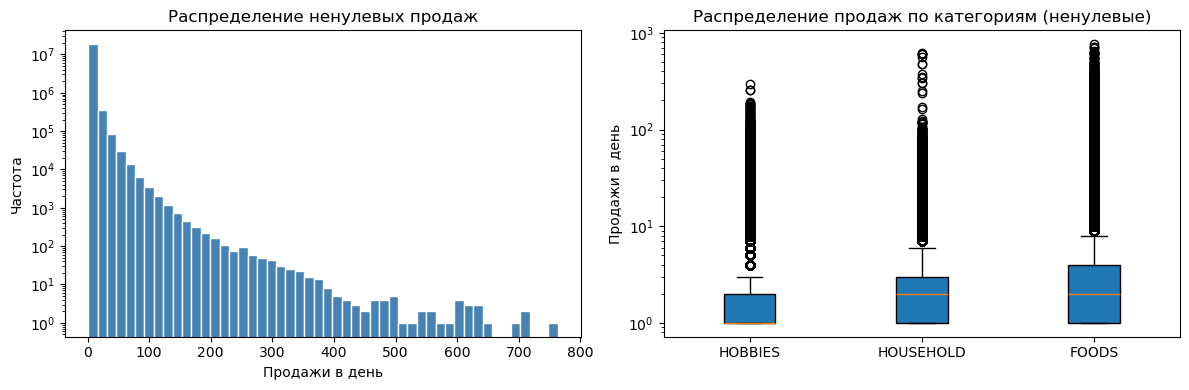

Max продаж за день (один SKU): 763
99-й перцентиль: 28
95-й перцентиль: 11


In [5]:
# Берём только ненулевые значения чтобы увидеть реальный спрос
nonzero_sales = sales_vals[sales_vals > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма ненулевых продаж
axes[0].hist(nonzero_sales, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение ненулевых продаж")
axes[0].set_xlabel("Продажи в день")
axes[0].set_ylabel("Частота")
axes[0].set_yscale("log")

# Boxplot по категориям
sales_long = sales_train[["cat_id"] + d_cols].melt(
    id_vars="cat_id", value_name="sales"
).query("sales > 0")

axes[1].boxplot(
    [sales_long[sales_long["cat_id"] == c]["sales"].values for c in sales_long["cat_id"].unique()],
    labels=sales_long["cat_id"].unique(), patch_artist=True
)
axes[1].set_title("Распределение продаж по категориям (ненулевые)")
axes[1].set_ylabel("Продажи в день")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Max продаж за день (один SKU): {nonzero_sales.max()}")
print(f"99-й перцентиль: {np.percentile(nonzero_sales, 99):.0f}")
print(f"95-й перцентиль: {np.percentile(nonzero_sales, 95):.0f}")

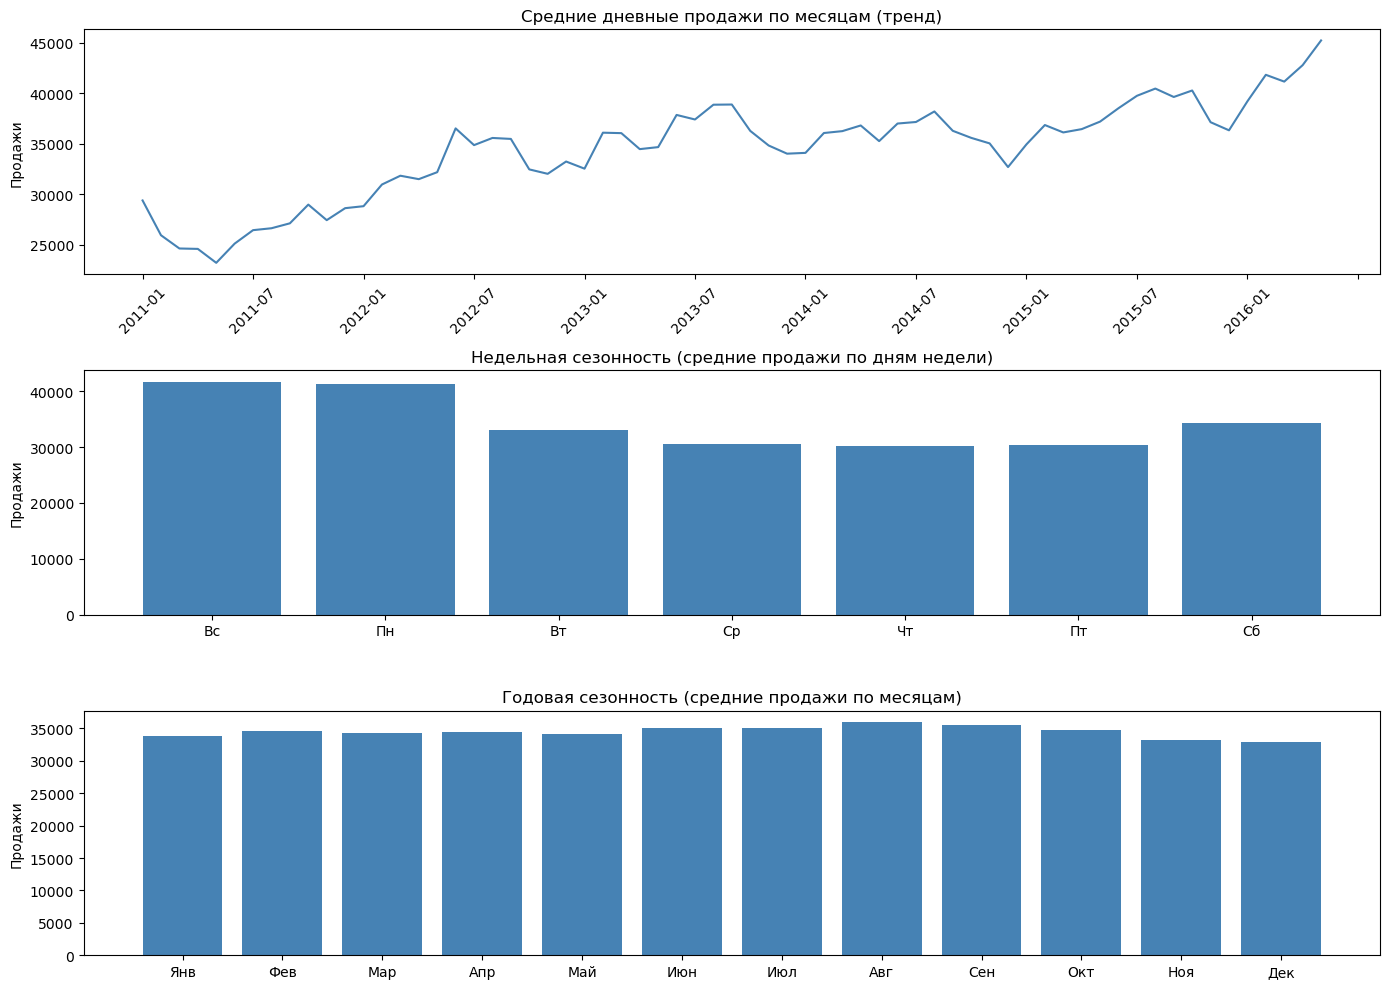

In [6]:
# Суммарные продажи по дням → джойним с календарём
daily_sales = sales_train[d_cols].sum(axis=0).reset_index()
daily_sales.columns = ["d", "total_sales"]
daily_sales = daily_sales.merge(calendar[["d", "date", "wday", "month", "year"]], on="d")
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Тренд по месяцам
monthly = daily_sales.groupby(["year", "month"])["total_sales"].mean().reset_index()
monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
axes[0].plot(monthly["period"], monthly["total_sales"], color="steelblue")
axes[0].set_title("Средние дневные продажи по месяцам (тренд)")
axes[0].set_ylabel("Продажи")
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(6))
axes[0].tick_params(axis='x', rotation=45)

# Недельная сезонность
wday_labels = {1: "Вс", 2: "Пн", 3: "Вт", 4: "Ср", 5: "Чт", 6: "Пт", 7: "Сб"}
wday_sales = daily_sales.groupby("wday")["total_sales"].mean()
axes[1].bar(wday_sales.index.map(wday_labels), wday_sales.values, color="steelblue")
axes[1].set_title("Недельная сезонность (средние продажи по дням недели)")
axes[1].set_ylabel("Продажи")

# Годовая сезонность
month_labels = ["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"]
month_sales = daily_sales.groupby("month")["total_sales"].mean()
axes[2].bar(range(1, 13), month_sales.values, color="steelblue")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_labels)
axes[2].set_title("Годовая сезонность (средние продажи по месяцам)")
axes[2].set_ylabel("Продажи")

plt.tight_layout()
plt.show()

In [7]:
from scipy import stats

# --- Недельная сезонность ---
groups_wday = [daily_sales[daily_sales["wday"] == w]["total_sales"].values 
               for w in sorted(daily_sales["wday"].unique())]

stat_wday, p_wday = stats.kruskal(*groups_wday)
print(f"Недельная сезонность (Kruskal-Wallis):")
print(f"  H = {stat_wday:.2f}, p = {p_wday:.4f} → {'есть' if p_wday < 0.05 else 'нет'} значимых различий\n")

# --- Годовая сезонность ---
groups_month = [daily_sales[daily_sales["month"] == m]["total_sales"].values 
                for m in sorted(daily_sales["month"].unique())]

stat_month, p_month = stats.kruskal(*groups_month)
print(f"Годовая сезонность (Kruskal-Wallis):")
print(f"  H = {stat_month:.2f}, p = {p_month:.4f} → {'есть' if p_month < 0.05 else 'нет'} значимых различий\n")

# --- Post-hoc: между какими именно днями недели различия? ---
from scipy.stats import mannwhitneyu
from itertools import combinations

wday_labels = {1:"Вс", 2:"Пн", 3:"Вт", 4:"Ср", 5:"Чт", 6:"Пт", 7:"Сб"}
print("Post-hoc (Mann-Whitney, Bonferroni) по дням недели:")
n_comparisons = len(list(combinations(range(1, 8), 2)))
for w1, w2 in combinations(sorted(daily_sales["wday"].unique()), 2):
    g1 = daily_sales[daily_sales["wday"] == w1]["total_sales"].values
    g2 = daily_sales[daily_sales["wday"] == w2]["total_sales"].values
    _, p = mannwhitneyu(g1, g2, alternative="two-sided")
    p_adj = min(p * n_comparisons, 1.0)  # Bonferroni correction
    if p_adj < 0.05:
        print(f"  {wday_labels[w1]} vs {wday_labels[w2]}: p_adj = {p_adj:.4f} ✓")

Недельная сезонность (Kruskal-Wallis):
  H = 754.38, p = 0.0000 → есть значимых различий

Годовая сезонность (Kruskal-Wallis):
  H = 22.95, p = 0.0180 → есть значимых различий

Post-hoc (Mann-Whitney, Bonferroni) по дням недели:
  Вс vs Вт: p_adj = 0.0000 ✓
  Вс vs Ср: p_adj = 0.0000 ✓
  Вс vs Чт: p_adj = 0.0000 ✓
  Вс vs Пт: p_adj = 0.0000 ✓
  Вс vs Сб: p_adj = 0.0000 ✓
  Пн vs Вт: p_adj = 0.0000 ✓
  Пн vs Ср: p_adj = 0.0000 ✓
  Пн vs Чт: p_adj = 0.0000 ✓
  Пн vs Пт: p_adj = 0.0000 ✓
  Пн vs Сб: p_adj = 0.0000 ✓
  Вт vs Ср: p_adj = 0.0000 ✓
  Вт vs Чт: p_adj = 0.0000 ✓
  Вт vs Пт: p_adj = 0.0000 ✓
  Вт vs Сб: p_adj = 0.0097 ✓
  Ср vs Сб: p_adj = 0.0000 ✓
  Чт vs Сб: p_adj = 0.0000 ✓
  Пт vs Сб: p_adj = 0.0000 ✓


## Вывод: статистическая проверка сезонности

**Недельная сезонность** — H=754.38, p<0.001 → подтверждена с высокой значимостью.
Post-hoc (Mann-Whitney + Bonferroni): Вс и Пн статистически отличаются от всех остальных дней
— выходные дают пик продаж. Вт-Пт однородны между собой (кроме Сб).

**Годовая сезонность** — H=22.95, p=0.018 → подтверждена, но слабее.
На агрегированном уровне месячные различия есть, но визуально небольшие (~10%).
На уровне отдельных категорий эффект может быть сильнее.

**Вывод для моделирования:** `wday` — обязательный признак. `month` или `week_of_year` — 
включить, но с меньшим приоритетом. Модель должна уметь обрабатывать недельную сезонность.

In [8]:
snap_event = calendar[["d", "event_name_1", "snap_CA", "snap_TX", "snap_WI"]].copy()
snap_event["has_event"] = snap_event["event_name_1"].notna()
snap_event["snap_any"]  = snap_event[["snap_CA", "snap_TX", "snap_WI"]].sum(axis=1) > 0

daily_sales = daily_sales.merge(snap_event, on="d", how="left")


event_sales    = daily_sales[daily_sales["has_event"]]["total_sales"]
no_event_sales = daily_sales[~daily_sales["has_event"]]["total_sales"]

stat, p = stats.mannwhitneyu(event_sales, no_event_sales, alternative="two-sided")
lift_event = event_sales.median() / no_event_sales.median() - 1
print(f"Праздники vs обычные дни:")
print(f"  Медиана в праздник: {event_sales.median():.0f}")
print(f"  Медиана в обычный:  {no_event_sales.median():.0f}")
print(f"  Lift: {lift_event:+.1%}, p = {p:.4f}\n")


snap_sales    = daily_sales[daily_sales["snap_any"]]["total_sales"]
no_snap_sales = daily_sales[~daily_sales["snap_any"]]["total_sales"]

stat, p = stats.mannwhitneyu(snap_sales, no_snap_sales, alternative="two-sided")
lift_snap = snap_sales.median() / no_snap_sales.median() - 1
print(f"SNAP-дни vs обычные дни:")
print(f"  Медиана в SNAP:    {snap_sales.median():.0f}")
print(f"  Медиана в обычный: {no_snap_sales.median():.0f}")
print(f"  Lift: {lift_snap:+.1%}, p = {p:.4f}\n")


baseline = no_event_sales.mean()
event_avg = (calendar[calendar["event_name_1"].notna()]
             .merge(daily_sales[["d", "total_sales"]], on="d")
             .groupby("event_name_1")["total_sales"]
             .mean()
             .sort_values(ascending=False))
print("Топ-10 событий по средним продажам (lift vs baseline):")
print((event_avg.head(10) / baseline - 1).map("{:+.1%}".format).to_string())

Праздники vs обычные дни:
  Медиана в праздник: 33956
  Медиана в обычный:  33817
  Lift: +0.4%, p = 0.3653

SNAP-дни vs обычные дни:
  Медиана в SNAP:    35697
  Медиана в обычный: 32020
  Lift: +11.5%, p = 0.0000

Топ-10 событий по средним продажам (lift vs baseline):
event_name_1
LaborDay          +21.8%
OrthodoxEaster    +19.1%
SuperBowl         +18.2%
Easter            +14.2%
Father's day       +5.6%
Pesach End         +4.8%
Mother's day       +4.3%
Purim End          +3.9%
Eid al-Fitr        +1.9%
ColumbusDay        +1.6%


## Вывод: праздники и SNAP-дни

**Праздники** — lift всего +0.4%, p=0.37 → статистически **не значимы** на агрегированном уровне.
Однако отдельные события дают заметный эффект: LaborDay (+21.8%), SuperBowl (+18.2%),
Easter (+14.2%). Это локальные всплески, которые усредняются по всей массе обычных дней.

**SNAP-дни** — lift +11.5%, p<0.001 → статистически **значимы**.
SNAP (государственные продовольственные субсидии) ощутимо поднимает спрос в дни выплат.

**Вывод для моделирования:**
- `snap_CA / snap_TX / snap_WI` — обязательные бинарные признаки
- Глобальный флаг `has_event` малоинформативен — лучше использовать
  one-hot или embedding по `event_name_1` / `event_type_1`
- Топовые события (LaborDay, SuperBowl, Easter) стоит выделить отдельными признаками

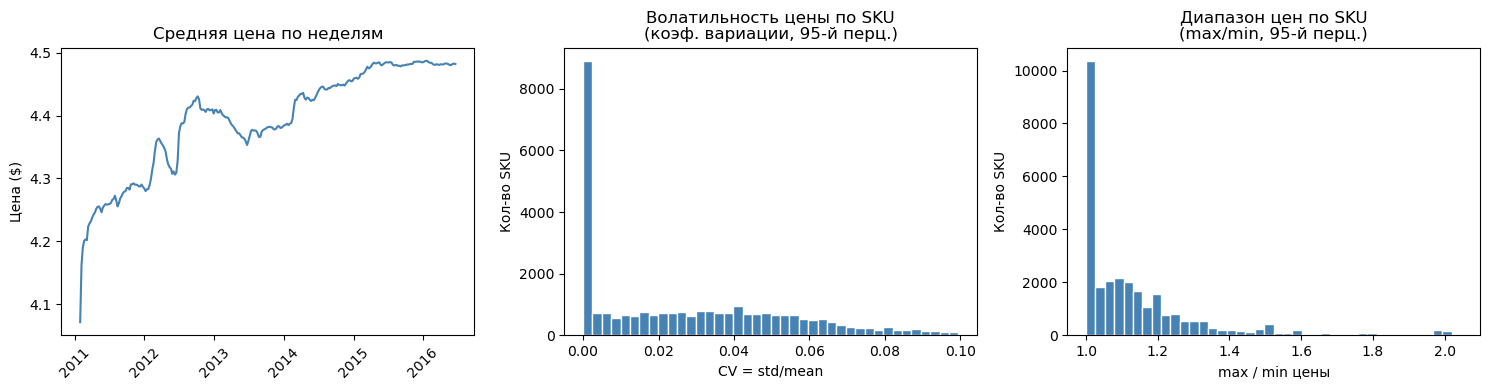

SKU с CV > 0.1 (заметная волатильность цены): 1504 (4.9%)
SKU с max/min > 1.5 (цена менялась >50%): 3374 (11.1%)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Тренд средней цены
axes[0].plot(price_trend["date"], price_trend["sell_price"], color="steelblue")
axes[0].set_title("Средняя цена по неделям")
axes[0].set_ylabel("Цена ($)")
axes[0].tick_params(axis="x", rotation=45)

# CV — обрезаем хвост выше 95-го перцентиля
cv_clip = price_changes["cv"].dropna()
cv_clip = cv_clip[cv_clip < cv_clip.quantile(0.95)]
axes[1].hist(cv_clip, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Волатильность цены по SKU\n(коэф. вариации, 95-й перц.)")
axes[1].set_xlabel("CV = std/mean")
axes[1].set_ylabel("Кол-во SKU")

# max/min — обрезаем хвост выше 95-го перцентиля
pr_clip = price_changes["price_range"].dropna()
pr_clip = pr_clip[pr_clip < pr_clip.quantile(0.95)]
axes[2].hist(pr_clip, bins=40, color="steelblue", edgecolor="white")
axes[2].set_title("Диапазон цен по SKU\n(max/min, 95-й перц.)")
axes[2].set_xlabel("max / min цены")
axes[2].set_ylabel("Кол-во SKU")

plt.tight_layout()
plt.show()

print(f"SKU с CV > 0.1 (заметная волатильность цены): "
      f"{(price_changes['cv'] > 0.1).sum()} "
      f"({(price_changes['cv'] > 0.1).mean():.1%})")
print(f"SKU с max/min > 1.5 (цена менялась >50%): "
      f"{(price_changes['price_range'] > 1.5).sum()} "
      f"({(price_changes['price_range'] > 1.5).mean():.1%})")

## Вывод: анализ цен

**Тренд:** средняя цена выросла с ~$4.1 до ~$4.5 за 5 лет (+10%) — умеренная инфляция,
без резких структурных сдвигов.

**Волатильность (CV):** 95% SKU имеют CV < 0.1 — цены в целом стабильны.
Только 4.9% SKU (1504) показывают заметную волатильность — кандидаты на промо-эффекты.

**Диапазон цен (max/min):** большинство SKU держится в диапазоне 1.0–1.2x,
но 11.1% SKU (3374) меняли цену более чем на 50% — явные промо или
переоценки, которые влияют на спрос.

**Вывод для моделирования:** `sell_price` — полезный признак, особенно в виде
относительного изменения к скользящему среднему (`price / rolling_mean_price`),
чтобы уловить промо-эффект. Абсолютная цена менее информативна из-за инфляции.

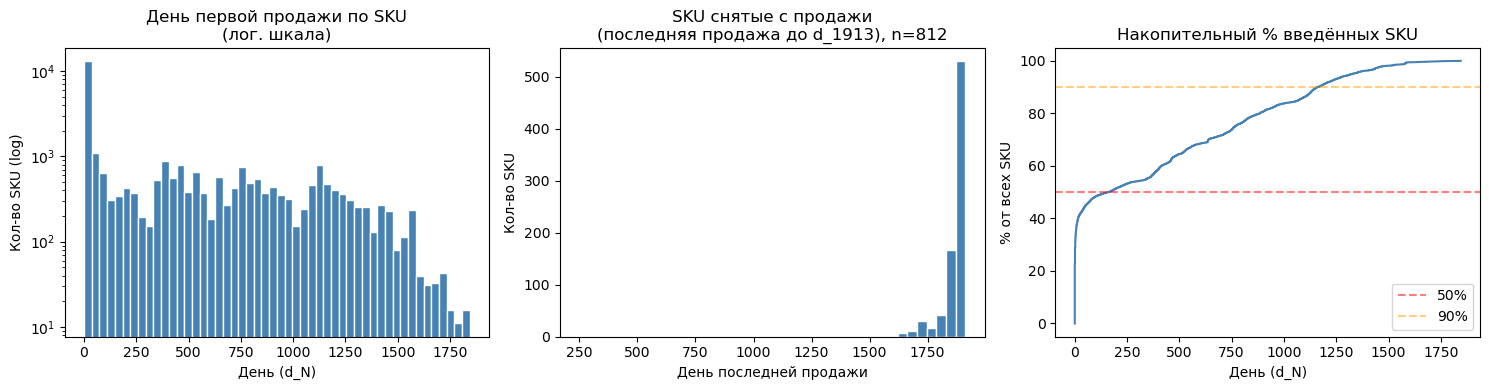

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# День первой продажи — лог шкала чтобы увидеть хвост
axes[0].hist(sku_activity["first_day"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("День первой продажи по SKU\n(лог. шкала)")
axes[0].set_xlabel("День (d_N)")
axes[0].set_ylabel("Кол-во SKU (log)")

# SKU которые реально исчезли — последняя продажа не в последних 28 днях
early_exit = sku_activity[sku_activity["last_day"] < (len(d_cols) - 28)]
axes[1].hist(early_exit["last_day"], bins=40, color="steelblue", edgecolor="white")
axes[1].set_title(f"SKU снятые с продажи\n(последняя продажа до d_{len(d_cols)-28}), n={len(early_exit)}")
axes[1].set_xlabel("День последней продажи")
axes[1].set_ylabel("Кол-во SKU")

# Накопительный % активных SKU по времени
activation = sku_activity["first_day"].sort_values()
cumulative  = np.arange(1, len(activation)+1) / len(activation) * 100
axes[2].plot(activation.values, cumulative, color="steelblue")
axes[2].set_title("Накопительный % введённых SKU")
axes[2].set_xlabel("День (d_N)")
axes[2].set_ylabel("% от всех SKU")
axes[2].axhline(50, color="red", linestyle="--", alpha=0.5, label="50%")
axes[2].axhline(90, color="orange", linestyle="--", alpha=0.5, label="90%")
axes[2].legend()

plt.tight_layout()
plt.show()

## Вывод: активность SKU

**Первая продажа:** ~13k SKU активны с самого начала (d_1), остальные 44% появляются
постепенно на протяжении всех 5 лет — датасет живой, ассортимент постоянно обновляется.

**Снятые с продажи:** всего 812 SKU (2.7%) прекратили продажи до конца горизонта —
практически нет "умерших" товаров. Всплеск у d_1880-1913 — это скорее временные
перебои, а не реальное снятие с продажи.

**Накопительный график:** 50% SKU введены к d_50, 90% — к d_1400.
Новые товары появляются равномерно на протяжении всего периода.

**Вывод для моделирования:** нужна маска активности — обучать модель только
на днях после первой продажи SKU. Для новых товаров (cold start) нужна
отдельная стратегия: либо признаки на уровне категории/департамента,
либо исключение из обучения первых N дней жизни товара.

Активных SKU (mean > 1): 8117 (26.6%)
Выбросов среди активных SKU: 157081 (0.997%)
Активных SKU хотя бы с одним выбросом: 7014 (86.4%)


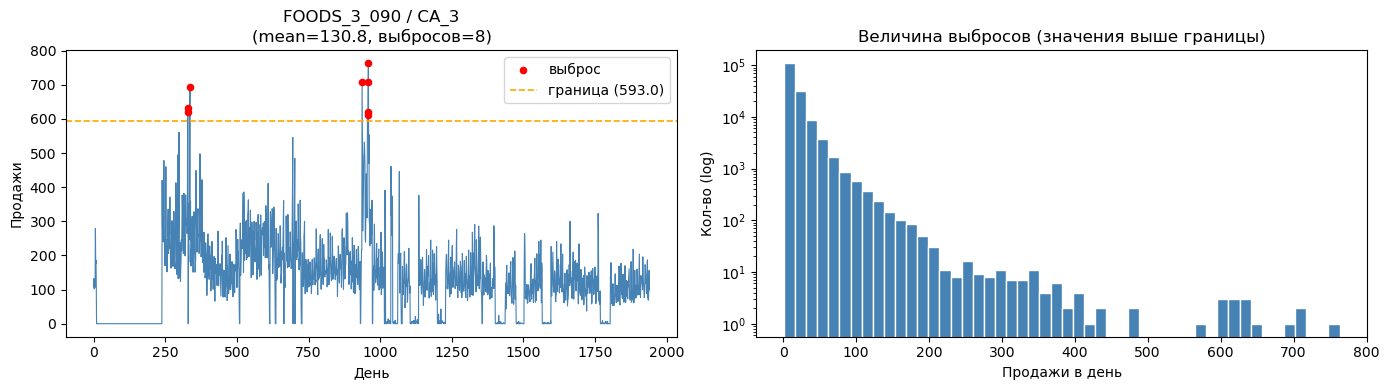

In [14]:
# Считаем среднее по SKU — берём только активные (mean > 1)
sku_mean = sales_matrix.mean(axis=1)
active_mask = sku_mean > 1
sales_active = sales_matrix[active_mask]

Q1  = sales_active.quantile(0.25, axis=1)
Q3  = sales_active.quantile(0.75, axis=1)
IQR = Q3 - Q1
upper_bound_active = Q3 + 3 * IQR

outlier_mask_active = sales_active.gt(upper_bound_active, axis=0)
n_outliers = outlier_mask_active.sum().sum()
n_sku_with_outliers = outlier_mask_active.any(axis=1).sum()

print(f"Активных SKU (mean > 1): {active_mask.sum()} ({active_mask.mean():.1%})")
print(f"Выбросов среди активных SKU: {n_outliers} ({n_outliers / sales_active.size:.3%})")
print(f"Активных SKU хотя бы с одним выбросом: "
      f"{n_sku_with_outliers} ({n_sku_with_outliers/len(sales_active):.1%})")

# Для визуализации берём SKU с высоким средним и выбросами
outlier_counts_active = outlier_mask_active.sum(axis=1)
candidate_skus = (sales_train.loc[active_mask]
                  .assign(n_outliers=outlier_counts_active.values,
                          mean_sales=sku_mean[active_mask].values)
                  .query("n_outliers > 0")
                  .sort_values("mean_sales", ascending=False))

top_sku_idx  = candidate_skus.index[0]
sku_series   = sales_matrix.loc[top_sku_idx]
sku_outliers = outlier_mask_active.loc[top_sku_idx]
ub           = upper_bound_active.loc[top_sku_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Временной ряд — топ SKU по среднему
axes[0].plot(sku_series.values, color="steelblue", linewidth=0.8)
axes[0].scatter(np.where(sku_outliers)[0],
                sku_series.values[sku_outliers.values],
                color="red", s=20, zorder=5, label="выброс")
axes[0].axhline(ub, color="orange", linestyle="--", linewidth=1.2, label=f"граница ({ub:.1f})")
axes[0].set_title(f"{sales_train.loc[top_sku_idx, 'item_id']} / "
                  f"{sales_train.loc[top_sku_idx, 'store_id']}\n"
                  f"(mean={sku_mean[top_sku_idx]:.1f}, выбросов={int(outlier_counts_active[top_sku_idx])})")
axes[0].set_xlabel("День")
axes[0].set_ylabel("Продажи")
axes[0].legend()

# Распределение magnitude выбросов (насколько превышают границу)
outlier_vals = sales_active.values[outlier_mask_active.values]
axes[1].hist(outlier_vals, bins=50, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Величина выбросов (значения выше границы)")
axes[1].set_xlabel("Продажи в день")
axes[1].set_ylabel("Кол-во (log)")

plt.tight_layout()
plt.show()

## Вывод: анализ выбросов

**Методология:** IQR-метод (Q3 + 3×IQR) применяется только к активным SKU
(mean > 1 продажи/день) — 8117 SKU (26.6%). На разреженных рядах метод
некорректен: Q1=Q3=0 → любая продажа становится "выбросом".

**Результат:** 0.997% значений активных SKU — выбросы. 86.4% активных SKU
имеют хотя бы один выброс — граница Q3+3×IQR достаточно консервативна,
большинство "выбросов" это умеренные всплески (10–50 единиц).

**Экстремальные случаи:** единичные значения 600–750 при средних ~130
(пример: FOODS_3_090/CA_3) — вероятно промо или ошибки данных.

**Стратегия обработки для моделирования:**
- Winsorizing на уровне 99.5-го перцентиля по SKU — заменяем экстремум
  на границу, не удаляем
- Добавить бинарный признак `is_outlier_day` — модель сама решит как
  на него реагировать
- Разреженные SKU (mean ≤ 1) обрабатывать отдельно — например,
  моделировать вероятность ненулевой продажи отдельно от её величины

Train:  d_1 — d_1885 (1885 дней)
Val 1:  d_1886 — d_1913 (28 дней)
Val 2:  d_1914 — d_1941 (28 дней)


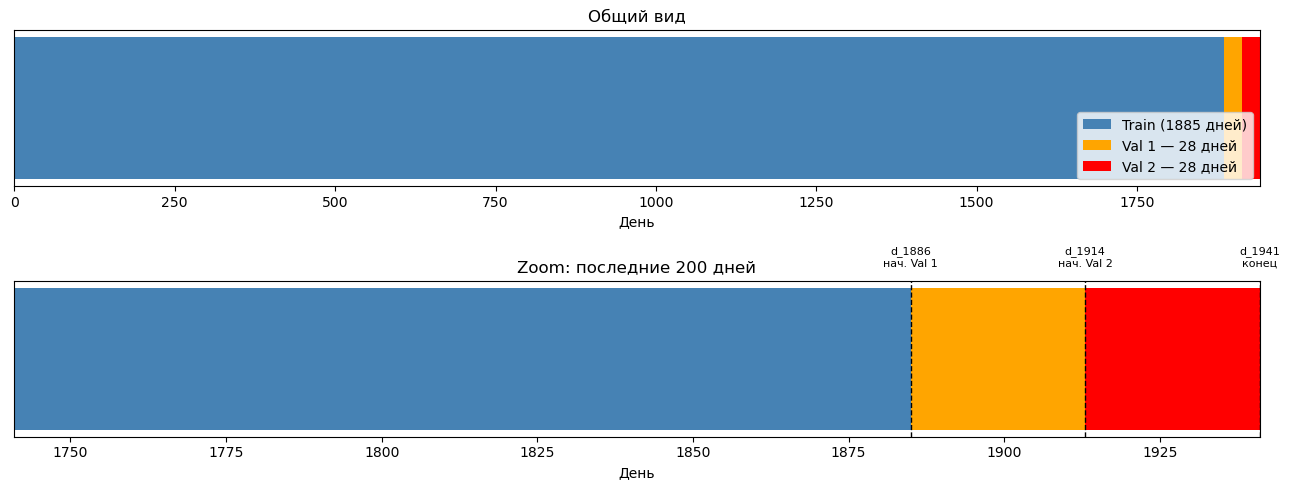


Итоговый датасет: (59181090, 19)
Пропуски в sell_price: 20.8% (товары без цены = ещё не в продаже)

Пример финального датасета:
                           id       item_id   dept_id  cat_id store_id state_id   d  sales       date  wm_yr_wk  wday  month  year event_name_1 event_type_1  snap_CA  snap_TX  snap_WI  sell_price
HOBBIES_1_001_CA_1_evaluation HOBBIES_1_001 HOBBIES_1 HOBBIES     CA_1       CA d_1      0 2011-01-29     11101     1      1  2011          NaN          NaN        0        0        0         NaN
HOBBIES_1_002_CA_1_evaluation HOBBIES_1_002 HOBBIES_1 HOBBIES     CA_1       CA d_1      0 2011-01-29     11101     1      1  2011          NaN          NaN        0        0        0         NaN
HOBBIES_1_003_CA_1_evaluation HOBBIES_1_003 HOBBIES_1 HOBBIES     CA_1       CA d_1      0 2011-01-29     11101     1      1  2011          NaN          NaN        0        0        0         NaN


In [18]:

# Train: d_1 — d_1885 (все кроме последних 56 дней)
# Val 1: d_1886 — d_1913 (28 дней) — validation window
# Val 2: d_1914 — d_1941 (28 дней) — evaluation window

HORIZON   = 28
TOTAL_DAYS = len(d_cols)          # 1941
val2_start = TOTAL_DAYS - HORIZON              # 1913
val1_start = val2_start - HORIZON              # 1885

train_cols = d_cols[:val1_start]
val1_cols  = d_cols[val1_start:val2_start]
val2_cols  = d_cols[val2_start:]

print(f"Train:  {train_cols[0]} — {train_cols[-1]} ({len(train_cols)} дней)")
print(f"Val 1:  {val1_cols[0]} — {val1_cols[-1]} ({len(val1_cols)} дней)")
print(f"Val 2:  {val2_cols[0]} — {val2_cols[-1]} ({len(val2_cols)} дней)")


fig, axes = plt.subplots(2, 1, figsize=(13, 5))

# Верхний — общий вид
axes[0].barh(0, len(train_cols), left=0,          height=0.4, color="steelblue", label=f"Train ({len(train_cols)} дней)")
axes[0].barh(0, len(val1_cols),  left=val1_start, height=0.4, color="orange",    label="Val 1 — 28 дней")
axes[0].barh(0, len(val2_cols),  left=val2_start, height=0.4, color="red",       label="Val 2 — 28 дней")
axes[0].set_xlim(0, TOTAL_DAYS)
axes[0].set_yticks([])
axes[0].set_xlabel("День")
axes[0].set_title("Общий вид")
axes[0].legend(loc="lower right")

# Нижний — zoom последние 200 дней
zoom_start = TOTAL_DAYS - 200
axes[1].barh(0, val1_start - zoom_start, left=zoom_start, height=0.4, color="steelblue")
axes[1].barh(0, len(val1_cols),          left=val1_start, height=0.4, color="orange")
axes[1].barh(0, len(val2_cols),          left=val2_start, height=0.4, color="red")

for x, label in [(val1_start, f"d_{val1_start+1}\nнач. Val 1"),
                 (val2_start, f"d_{val2_start+1}\nнач. Val 2"),
                 (TOTAL_DAYS, f"d_{TOTAL_DAYS}\nконец")]:
    axes[1].axvline(x, color="black", linestyle="--", linewidth=1)
    axes[1].text(x, 0.26, label, ha="center", fontsize=8)

axes[1].set_xlim(zoom_start, TOTAL_DAYS)
axes[1].set_yticks([])
axes[1].set_xlabel("День")
axes[1].set_title("Zoom: последние 200 дней")

plt.tight_layout()
plt.show()


# Wide → Long формат + календарь + цены
sales_long = (sales_train[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"] + d_cols]
              .melt(id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
                    var_name="d", value_name="sales"))

# Джойн с календарём
sales_long = sales_long.merge(
    calendar[["d", "date", "wm_yr_wk", "wday", "month", "year",
              "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]],
    on="d", how="left"
)

# Джойн с ценами
sales_long = sales_long.merge(sell_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

print(f"\nИтоговый датасет: {sales_long.shape}")
print(f"Пропуски в sell_price: {sales_long['sell_price'].isna().mean():.1%} "
      f"(товары без цены = ещё не в продаже)")
print(f"\nПример финального датасета:")
print(sales_long.head(3).to_string(index=False))

Репрезентативные SKU:
        item_id store_id    cat_id  mean_sales
    FOODS_3_090     CA_3     FOODS  130.787738
  HOBBIES_1_234     CA_3   HOBBIES   15.612056
HOUSEHOLD_1_118     CA_3 HOUSEHOLD   22.678001


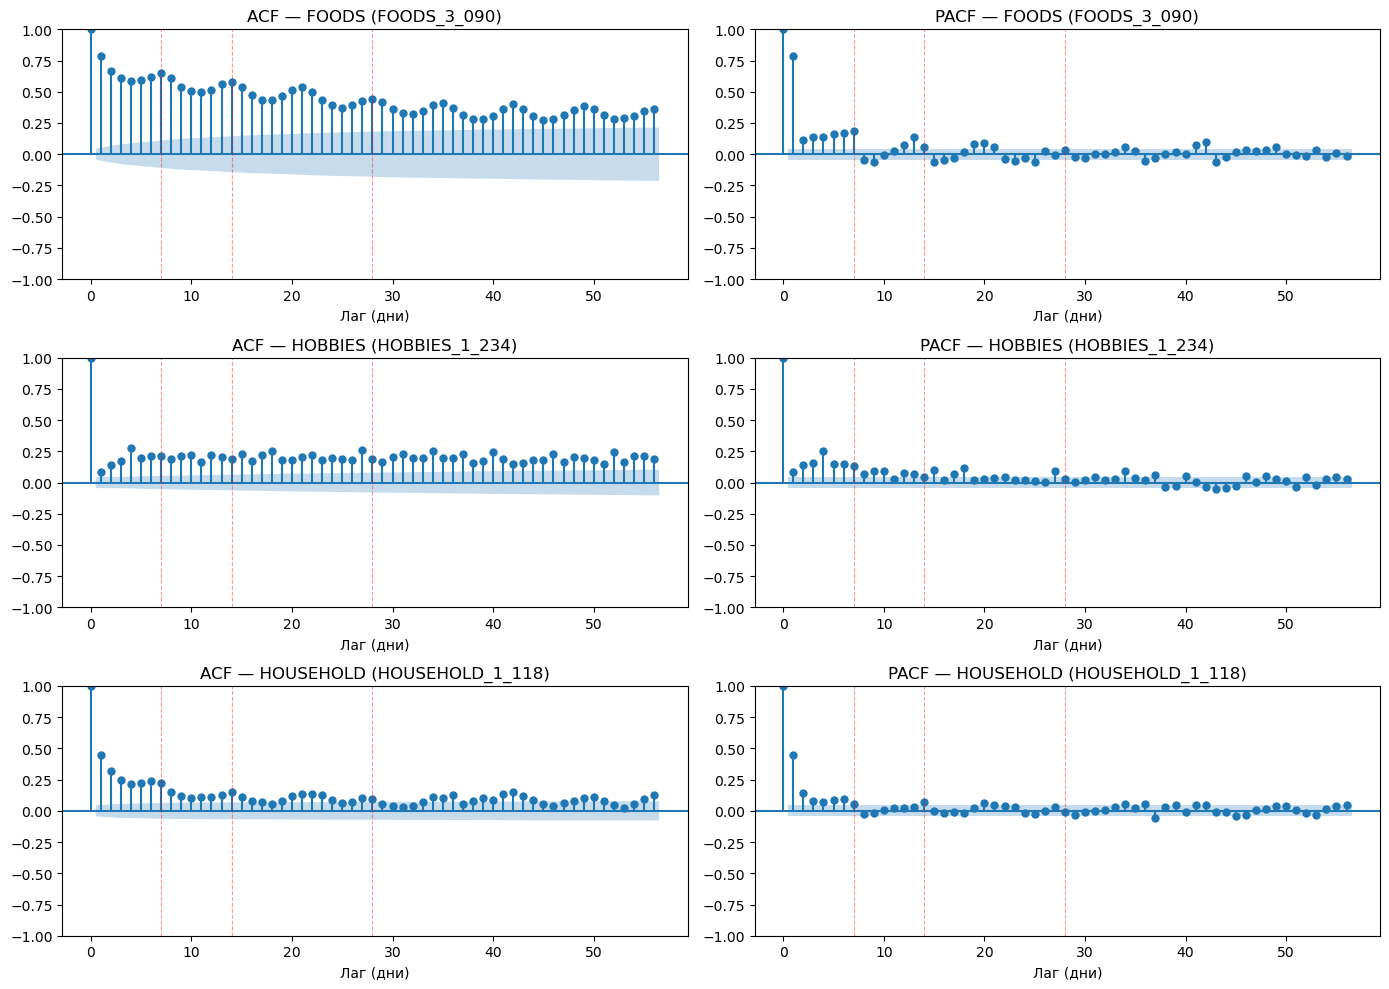

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Берём по одному репрезентативному SKU из каждой категории
# Выбираем активные SKU с наибольшим средним спросом
representative_skus = (
    sales_train[["item_id", "cat_id", "store_id"]]
    .assign(mean_sales=sales_matrix.mean(axis=1))
    .query("mean_sales > 5")
    .groupby("cat_id")
    .apply(lambda x: x.nlargest(1, "mean_sales"))
    .reset_index(drop=True)
)
print("Репрезентативные SKU:")
print(representative_skus[["item_id", "store_id", "cat_id", "mean_sales"]].to_string(index=False))

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, row in representative_skus.iterrows():
    idx = sales_train[
        (sales_train["item_id"] == row["item_id"]) &
        (sales_train["store_id"] == row["store_id"])
    ].index[0]
    
    series = sales_matrix.loc[idx].values.astype(float)
    cat    = row["cat_id"]
    
    plot_acf(series,  lags=56, ax=axes[i][0], title=f"ACF — {cat} ({row['item_id']})")
    plot_pacf(series, lags=56, ax=axes[i][1], title=f"PACF — {cat} ({row['item_id']})", method="ywm")
    
    # Подсвечиваем лаги 7, 14, 28
    for ax in axes[i]:
        for lag in [7, 14, 28]:
            ax.axvline(lag, color="red", linestyle="--", alpha=0.4, linewidth=0.8)
        ax.set_xlabel("Лаг (дни)")

plt.tight_layout()
plt.show()

## Вывод: ACF/PACF анализ

**FOODS (FOODS_3_090, mean=131):**
ACF медленно затухает — выраженный тренд + сильная недельная сезонность.
Чёткие пики на лагах 7, 14, 21 в ACF подтверждают 7-дневный цикл.
PACF значим только на лагах 1–2 и слабо на 7 — структура AR(1-2) + сезонность.

**HOBBIES (HOBBIES_1_234, mean=16):**
ACF значительно слабее, но пики на кратных 7 всё равно видны.
PACF почти полностью гасится после лага 2 — ряд менее автокоррелирован,
ближе к шуму с недельным паттерном.

**HOUSEHOLD (HOUSEHOLD_1_118, mean=23):**
Промежуточный случай: ACF затухает быстрее чем FOODS, пики на 7/14 есть,
но слабее. PACF значим только на лагах 1 и 7.

**Вывод для моделирования:**
Лаги 7, 14, 28 статистически обоснованы для всех трёх категорий —
пики ACF явно совпадают с красными пунктирами.
Дополнительно оправданы лаги 1, 2 (краткосрочная автокорреляция).
Для FOODS также лаг 365 (годовая сезонность) — ACF не затухает до нуля
даже на лаге 56, что говорит о долгой памяти ряда.

**Рекомендуемый набор лагов для feature engineering:**
`[1, 2, 7, 14, 28, 56]` + скользящие средние на окнах 7/28/56 дней.

## Ограничения датасета: M5 (Walmart, США) → РФ e-commerce

### Чем M5 отличается от целевого домена

| Характеристика | M5 (Walmart, США) | Целевой домен (РФ e-commerce) |
|---|---|---|
| Тип канала | Офлайн супермаркет | Онлайн магазин |
| Масштаб | Крупная сеть, 10 магазинов | Малый бизнес, 1k–50k SKU |
| Спрос | Стабильный, предсказуемый | Более волатильный, cold start чаще |
| Сезонность | Американские праздники (LaborDay, SuperBowl) | Российские праздники (НГ, 8 марта, майские) |
| SNAP-эффект | Есть, значим (+11.5%) | Аналога нет |
| Горизонт данных | 5.5 лет непрерывно | Часто < 1–2 лет у малого бизнеса |
| Ценообразование | Медленные изменения, инфляция ~10% за 5 лет | Возможны резкие переоценки, акции |
| Категории | FOODS, HOBBIES, HOUSEHOLD | Произвольные, зависят от ниши |

### Конкретные риски для модели

**1. Сезонность не переносится напрямую.**
Паттерны спроса привязаны к американскому календарю. Модель, обученная
на M5, не будет знать про январские праздники в РФ, майские выходные
или Black Friday в ноябре. Признаки `event_name_1` нужно полностью
переработать под российский календарь.

**2. SNAP-эффект отсутствует в РФ.**
SNAP даёт +11.5% lift и является одним из сильных признаков в M5.
В российском e-commerce прямого аналога нет — этот признак выпадет,
и его вклад нужно будет чем-то компенсировать (например, дни зарплат,
начало месяца).

**3. Масштаб и структура спроса.**
Walmart — крупнейший ритейлер США с высоким и стабильным трафиком.
Малый e-commerce имеет более высокую долю intermittent demand,
больше cold start ситуаций и менее предсказуемый спрос.
Модель может систематически переоценивать уверенность прогноза.

**4. Горизонт обучения.**
Данные с 2011 года могут содержать устаревшие паттерны поведения
покупателей. Для РФ e-commerce скорее всего будет доступно
1–2 года истории, а не 5.5 лет. Это меняет выбор моделей:
длинные лаги (lag_365) могут быть недоступны.

### Как это учитывается в проекте

- M5 используется как **прокси-датасет** для разработки и валидации
  методологии, а не как продакшн-данные
- Архитектура признаков проектируется так, чтобы календарные фичи
  были **заменяемы** (российский календарь вместо американского)
- SNAP-признаки в финальном сервисе заменяются на **начало месяца /
  день зарплаты** как прокси
- Модель будет тестироваться на реальных РФ e-commerce данных
  на этапе Evaluation — обобщаемость проверяется эмпирически

## Отбор данных: нужны ли все данные?

### Вопрос 1: что делать с ultra-sparse SKU (>90% нулей)?

Таких SKU 5 133 (16.8% от всех). Варианты:

| Стратегия | Плюсы | Минусы |
|---|---|---|
| Исключить из обучения | Чище обучающая выборка, меньше шума | Теряем часть ассортимента, нет прогноза для них |
| Моделировать отдельно (Croston / ADIDA) | Специализированные методы для intermittent demand | Усложняет пайплайн, нужен отдельный inference |
| Оставить как есть | Просто, ничего не теряем | Модель будет систематически переоценивать нули |
| Two-stage: сначала P(sale>0), потом объём | Разделяем задачи — честнее для разреженных рядов | Сложнее, два отдельных предсказания |

**Решение для данного проекта:**
Разбить SKU на две группы по порогу mean > 1:
- **Активные (26.6%)** — моделировать основной LightGBM с квантилями
- **Sparse (73.4%)** — на первом этапе исключить из обучения,
  зафиксировать как ограничение. На следующем этапе — рассмотреть
  Croston или two-stage подход.

Это соответствует приоритету проекта: сначала работающий сервис
для активных SKU, потом расширение покрытия.

### Вопрос 2: нужны ли все 1941 день (2011–2016)?

**Аргументы за полный горизонт:**
- Больше данных для оценки годовой сезонности (нужно минимум 2–3 цикла)
- ACF показал долгую память у FOODS — лаг 365 обоснован
- Для LightGBM больше строк = лучше обобщение

**Аргументы за сокращение (последние 2–3 года):**
- Паттерны 2011–2013 могут устареть — другой состав ассортимента,
  другое поведение покупателей
- Целевой домен (РФ e-commerce) редко имеет >2 лет истории —
  обучение на длинном горизонте создаёт несоответствие
- Drift: средние продажи выросли с 24k до 45k/день — ранние данные
  из другого "режима" работы магазинов

**Решение:**
Обучать на полном горизонте (d_1–d_1885), но добавить `age_of_series`
как признак — количество дней с момента первой продажи SKU.
Это позволит модели самой взвесить "старые" и "новые" наблюдения.
Дополнительно: провести эксперимент на этапе моделирования —
сравнить качество модели обученной на последних 2 vs 5 годах.

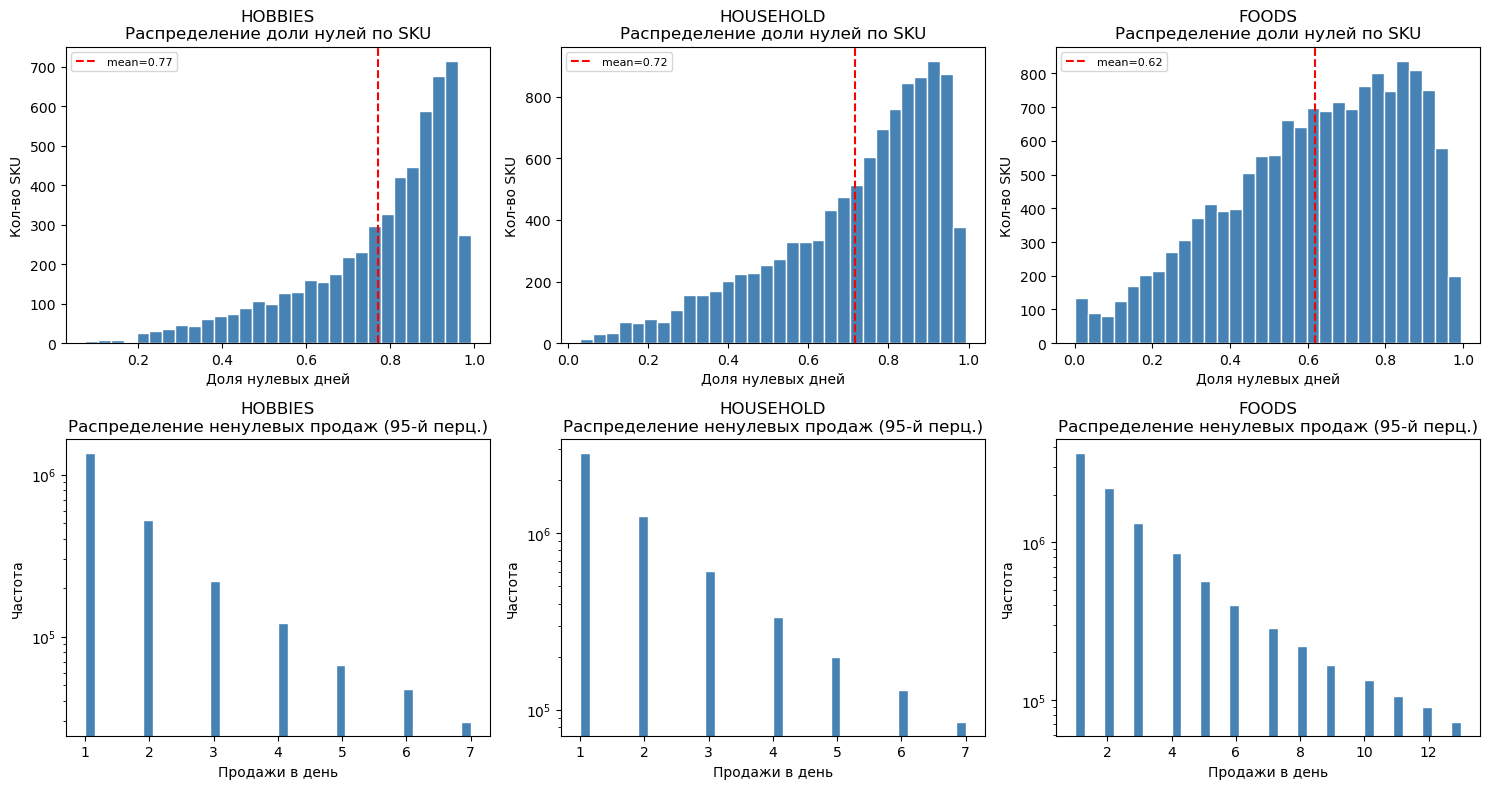

   cat_id  n_sku zero_frac sparse_sku_pct median_nonzero p95_nonzero mean_daily
  HOBBIES   5650     77.1%          29.5%            1.0         8.0       0.57
HOUSEHOLD  10470     71.6%          19.8%            2.0         8.0       0.73
    FOODS  14370     61.8%           9.7%            2.0        14.0       1.65


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
categories = sales_train["cat_id"].unique()

for i, cat in enumerate(categories):
    mask = sales_train["cat_id"] == cat
    cat_matrix = sales_matrix[mask]
    
    # Доля нулей по SKU внутри категории
    zeros_per_sku = (cat_matrix == 0).mean(axis=1)
    
    # Верхний ряд — распределение доли нулей по SKU
    axes[0][i].hist(zeros_per_sku, bins=30, color="steelblue", edgecolor="white")
    axes[0][i].set_title(f"{cat}\nРаспределение доли нулей по SKU")
    axes[0][i].set_xlabel("Доля нулевых дней")
    axes[0][i].set_ylabel("Кол-во SKU")
    axes[0][i].axvline(zeros_per_sku.mean(), color="red", 
                       linestyle="--", label=f"mean={zeros_per_sku.mean():.2f}")
    axes[0][i].legend(fontsize=8)
    
    # Нижний ряд — распределение ненулевых продаж
    nonzero = cat_matrix.values[cat_matrix.values > 0]
    axes[1][i].hist(nonzero[nonzero < np.percentile(nonzero, 95)], 
                    bins=40, color="steelblue", edgecolor="white")
    axes[1][i].set_title(f"{cat}\nРаспределение ненулевых продаж (95-й перц.)")
    axes[1][i].set_xlabel("Продажи в день")
    axes[1][i].set_ylabel("Частота")
    axes[1][i].set_yscale("log")

plt.tight_layout()
plt.show()

# Сводная таблица по категориям
summary = []
for cat in categories:
    mask = sales_train["cat_id"] == cat
    cat_matrix = sales_matrix[mask]
    nonzero = cat_matrix.values[cat_matrix.values > 0]
    zeros_per_sku = (cat_matrix == 0).mean(axis=1)
    
    summary.append({
        "cat_id"        : cat,
        "n_sku"         : mask.sum(),
        "zero_frac"     : f"{(cat_matrix == 0).mean().mean():.1%}",
        "sparse_sku_pct": f"{(zeros_per_sku > 0.9).mean():.1%}",
        "median_nonzero": f"{np.median(nonzero):.1f}",
        "p95_nonzero"   : f"{np.percentile(nonzero, 95):.1f}",
        "mean_daily"    : f"{cat_matrix.mean().mean():.2f}",
    })

print(pd.DataFrame(summary).to_string(index=False))

## Вывод: категориальный анализ FOODS / HOBBIES / HOUSEHOLD

| Метрика | HOBBIES | HOUSEHOLD | FOODS |
|---|---|---|---|
| Кол-во SKU | 5 650 | 10 470 | 14 370 |
| Доля нулей | 77.1% | 71.6% | 61.8% |
| Ultra-sparse SKU (>90% нулей) | 29.5% | 19.8% | 9.7% |
| Медиана ненулевых продаж | 1.0 | 2.0 | 2.0 |
| 95-й перцентиль | 8.0 | 8.0 | 14.0 |
| Среднее дневных продаж | 0.57 | 0.73 | 1.65 |

**FOODS** — наиболее активная категория: меньше нулей (61.8%),
выше средний спрос (1.65/день), шире хвост (p95=14).
Наименее разреженная — 9.7% ultra-sparse SKU.
Именно FOODS даёт основной объём продаж в датасете.

**HOBBIES** — самая проблемная категория для моделирования:
77.1% нулей, почти треть SKU (29.5%) ultra-sparse,
медиана ненулевых продаж = 1. Классический intermittent demand.

**HOUSEHOLD** — промежуточный случай: умеренная разреженность,
но 19.8% ultra-sparse SKU.

**Вывод для моделирования:**
Категории принципиально разные — глобальная модель будет
компромиссом. Рекомендуется:
- Для FOODS: стандартный LightGBM с квантилями
- Для HOBBIES: отдельная стратегия (Croston / two-stage)
  или исключение ultra-sparse SKU
- `cat_id` и `dept_id` — обязательные признаки,
  лучше всего через embedding или target encoding

Корреляция цена–продажи по SKU:
count    6791.000
mean       -0.057
std         0.190
min        -0.789
25%        -0.169
50%        -0.052
75%         0.052
max         0.835
Name: price_sales_corr, dtype: float64

Доля SKU с отрицательной корреляцией (цена↑ → продажи↓): 53.3%


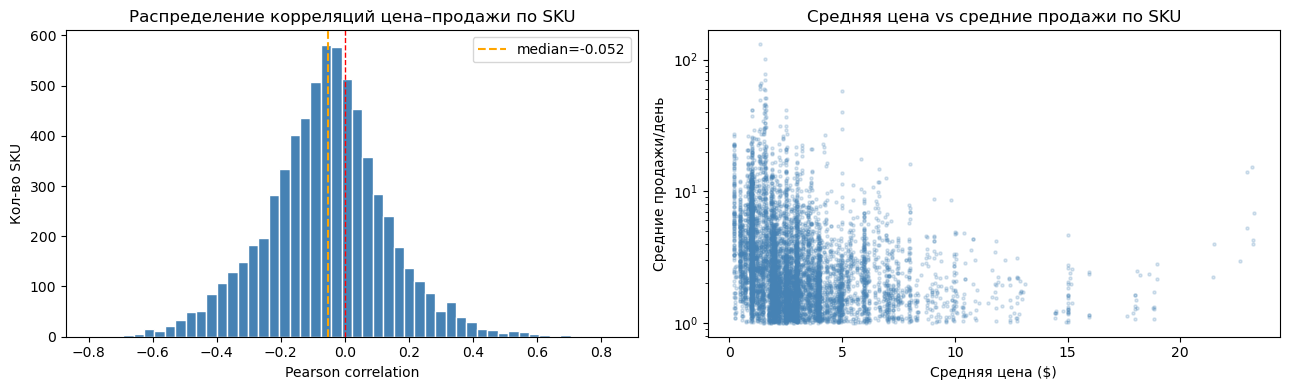

In [21]:
# Переводим в long только активные SKU для скорости
active_idx = sales_matrix[sales_matrix.mean(axis=1) > 1].index

sales_long_active = (
    sales_train.loc[active_idx, ["item_id", "store_id"] + d_cols]
    .melt(id_vars=["item_id", "store_id"], var_name="d", value_name="sales")
    .merge(calendar[["d", "wm_yr_wk"]], on="d", how="left")
    .merge(sell_prices, on=["item_id", "store_id", "wm_yr_wk"], how="left")
    .dropna(subset=["sell_price"])
)

# Относительное изменение цены и продаж по SKU
price_sales_corr = (
    sales_long_active
    .groupby(["item_id", "store_id"])
    .apply(lambda g: g[["sell_price", "sales"]].corr().iloc[0, 1])
    .reset_index(name="price_sales_corr")
)

print("Корреляция цена–продажи по SKU:")
print(price_sales_corr["price_sales_corr"].describe().round(3))
print(f"\nДоля SKU с отрицательной корреляцией (цена↑ → продажи↓): "
      f"{(price_sales_corr['price_sales_corr'] < 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Распределение корреляций
axes[0].hist(price_sales_corr["price_sales_corr"], bins=50,
             color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].axvline(price_sales_corr["price_sales_corr"].median(),
                color="orange", linestyle="--",
                label=f"median={price_sales_corr['price_sales_corr'].median():.3f}")
axes[0].set_title("Распределение корреляций цена–продажи по SKU")
axes[0].set_xlabel("Pearson correlation")
axes[0].set_ylabel("Кол-во SKU")
axes[0].legend()

# Scatter: средняя цена vs средние продажи по SKU
sku_stats = (sales_long_active
             .groupby(["item_id", "store_id"])
             .agg(mean_price=("sell_price", "mean"),
                  mean_sales=("sales", "mean"))
             .reset_index())

axes[1].scatter(sku_stats["mean_price"], sku_stats["mean_sales"],
                alpha=0.2, s=5, color="steelblue")
axes[1].set_title("Средняя цена vs средние продажи по SKU")
axes[1].set_xlabel("Средняя цена ($)")
axes[1].set_ylabel("Средние продажи/день")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## Вывод: связь цены с продажами

**Корреляция цена–продажи (Pearson по SKU):**
Медиана = -0.052 — слабая отрицательная связь, почти нулевая.
53.3% SKU имеют отрицательную корреляцию (цена↑ → продажи↓) —
это ожидаемо экономически, но эффект очень слабый.

**Scatter средняя цена vs средние продажи:**
Дешёвые товары (1–3 доллара)имеют самый широкий разброс продаж —
от 1 до 100+ единиц/день. Дорогие товары ($10–25) стабильно
продаются мало. Это не столько ценовой эффект, сколько
структурный — дешёвые товары это в основном FOODS с высоким
оборотом.

**Почему корреляция слабая:**
Pearson по уровням цена/продажи некорректен — есть общий тренд
роста (confounding). Правильнее смотреть на изменения:
Δцена vs Δпродажи в моменты переоценки. Для данного EDA
достаточно зафиксировать: прямой линейной связи нет,
цена работает через нелинейные и категориальные эффекты.

**Вывод для моделирования:**
- Абсолютная цена слабо предсказывает спрос
- Полезнее использовать `price / rolling_mean_price_28d` —
  относительное отклонение от "нормальной" цены SKU
- Бинарный флаг `is_promo` (цена ниже среднего на >10%) —
  отдельный признак для промо-эффекта

## Стратегия валидации: walk-forward vs static split

### Что использовали

Static temporal split:
- Train:  d_1 — d_1885
- Val 1:  d_1886 — d_1913 (28 дней, для разработки)
- Val 2:  d_1914 — d_1941 (28 дней, финальный holdout)

### Почему не walk-forward на этапе EDA

Walk-forward (rolling-origin) validation — золотой стандарт
для временных рядов. Схема: обучаем на d_1–d_N, предсказываем
d_{N+1}–d_{N+28}, сдвигаем окно, повторяем.

Для EDA это избыточно — walk-forward нужен на этапе
**подбора гиперпараметров и сравнения моделей**, не для
описания данных.

### План на этап моделирования

Fold 1: train d_1–d_1773  → predict d_1774–d_1801

Fold 2: train d_1–d_1801  → predict d_1802–d_1829

Fold 3: train d_1–d_1829  → predict d_1830–d_1857

Fold 4: train d_1–d_1857  → predict d_1858–d_1885

─────────────────────────────────────────────────

Val 1:  train d_1–d_1885  → predict d_1886–d_1913  ← разработка

Val 2:  train d_1–d_1913  → predict d_1914–d_1941  ← финал


**Почему горизонт 28 дней:**
- Соответствует конкурсной структуре M5
- Покрывает ровно 4 недели — полный цикл недельной сезонности
- Достаточно для операционного планирования запасов
  (типичный горизонт пополнения склада в e-commerce)
- Кратен 7 → корректная оценка недельных паттернов без
  смещения по дням недели между train и val

**Почему не 14 или 56 дней:**
- 14 дней — слишком короткий горизонт для планирования закупок,
  недостаточно для оценки месячных паттернов
- 56 дней — слишком длинный, теряем 4 fold'а истории,
  модель прогнозирует слишком далеко → рост неопределённости

### Метрики по фолдам

Для каждого fold считаем Pinball Loss на квантилях 0.1/0.5/0.9.
Финальная метрика — среднее по всем фолдам. Это защищает
от случайно "удачного" или "неудачного" одного окна.

SNAP lift по штатам:

  CA: median SNAP=15442, no-SNAP=14387, lift=+7.3%, p=0.0000
  TX: median SNAP=10424, no-SNAP=9314, lift=+11.9%, p=0.0000
  WI: median SNAP=10846, no-SNAP=8744, lift=+24.0%, p=0.0000


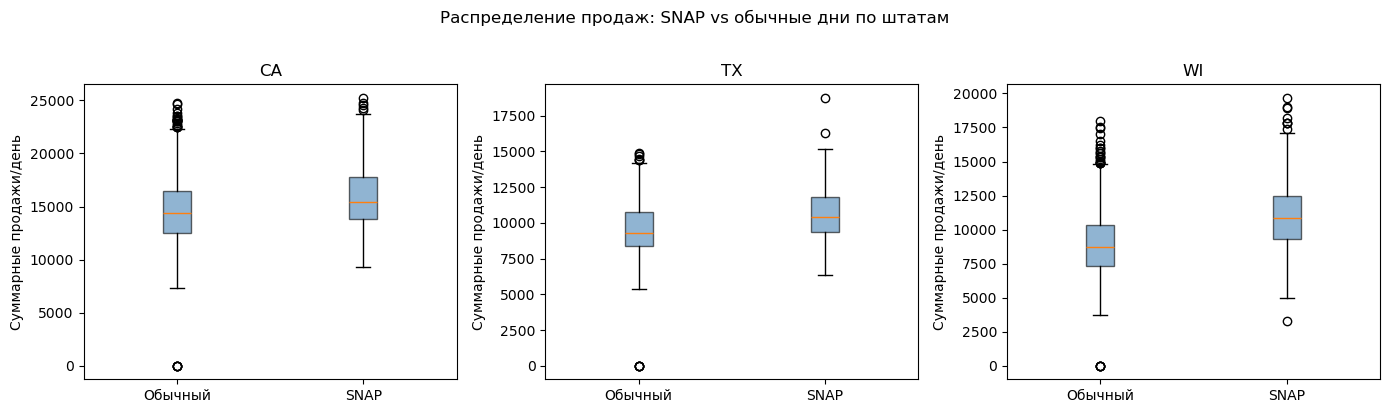

In [22]:
# Lift SNAP отдельно по каждому штату
snap_cols = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}
store_to_state = sales_train[["store_id", "state_id"]].drop_duplicates()

print("SNAP lift по штатам:\n")
for state, snap_col in snap_cols.items():
    # Продажи только по магазинам этого штата
    stores = store_to_state[store_to_state["state_id"] == state]["store_id"].tolist()
    state_mask = sales_train["store_id"].isin(stores)
    state_idx = sales_train[state_mask].index
    
    state_daily = (sales_matrix.loc[state_idx].sum(axis=0)
                   .reset_index()
                   .rename(columns={"index": "d", 0: "total_sales"}))
    state_daily = state_daily.merge(
        calendar[["d", snap_col]], on="d", how="left"
    )
    
    snap_s    = state_daily[state_daily[snap_col] == 1]["total_sales"]
    no_snap_s = state_daily[state_daily[snap_col] == 0]["total_sales"]
    
    stat, p = stats.mannwhitneyu(snap_s, no_snap_s, alternative="two-sided")
    lift = snap_s.median() / no_snap_s.median() - 1
    print(f"  {state}: median SNAP={snap_s.median():.0f}, "
          f"no-SNAP={no_snap_s.median():.0f}, "
          f"lift={lift:+.1%}, p={p:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (state, snap_col) in enumerate(snap_cols.items()):
    stores = store_to_state[store_to_state["state_id"] == state]["store_id"].tolist()
    state_idx = sales_train[sales_train["store_id"].isin(stores)].index
    state_daily = (sales_matrix.loc[state_idx].sum(axis=0)
                   .reset_index()
                   .rename(columns={"index": "d", 0: "total_sales"}))
    state_daily = state_daily.merge(calendar[["d", snap_col]], on="d", how="left")
    
    snap_days   = state_daily[state_daily[snap_col] == 1]["total_sales"]
    no_snap_days = state_daily[state_daily[snap_col] == 0]["total_sales"]
    
    axes[i].boxplot([no_snap_days, snap_days],
                    labels=["Обычный", "SNAP"],
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(f"{state}")
    axes[i].set_ylabel("Суммарные продажи/день")

plt.suptitle("Распределение продаж: SNAP vs обычные дни по штатам", y=1.02)
plt.tight_layout()
plt.show()

## Вывод: SNAP-эффект по штатам

| Штат | Lift | p-value |
|---|---|---|
| CA (Калифорния) | +7.3% | <0.001 |
| TX (Техас) | +11.9% | <0.001 |
| WI (Висконсин) | +24.0% | <0.001 |

Все три штата показывают значимый SNAP-эффект, но величина
существенно различается: WI реагирует в 3x сильнее чем CA.

Глобальный lift +11.5% из ячейки 8 — это средневзвешенное,
которое скрывало региональную неоднородность.

**Причина различий:** SNAP-программы в разных штатах работают
по-разному — отличаются дни выплат, охват населения и доля
SNAP-транзакций в обороте конкретных магазинов.

**Вывод для моделирования:** использовать три отдельных признака
`snap_CA`, `snap_TX`, `snap_WI` — не агрегировать в один `snap_any`.
Модель должна обучиться на разной силе эффекта по регионам.

Ранние SKU (first_day < 365):  17055 (55.9%)
Поздние SKU (first_day >= 365): 13435 (44.1%)

Ранние:
  Доля нулей (медиана по SKU): 62.3%
  Среднее дневных продаж:      1.51
  Медиана ненулевых продаж:    2.0
  Ultra-sparse (>90% нулей):   7.3%

Поздние:
  Доля нулей (медиана по SKU): 83.1%
  Среднее дневных продаж:      0.65
  Медиана ненулевых продаж:    2.0
  Ultra-sparse (>90% нулей):   29.0%



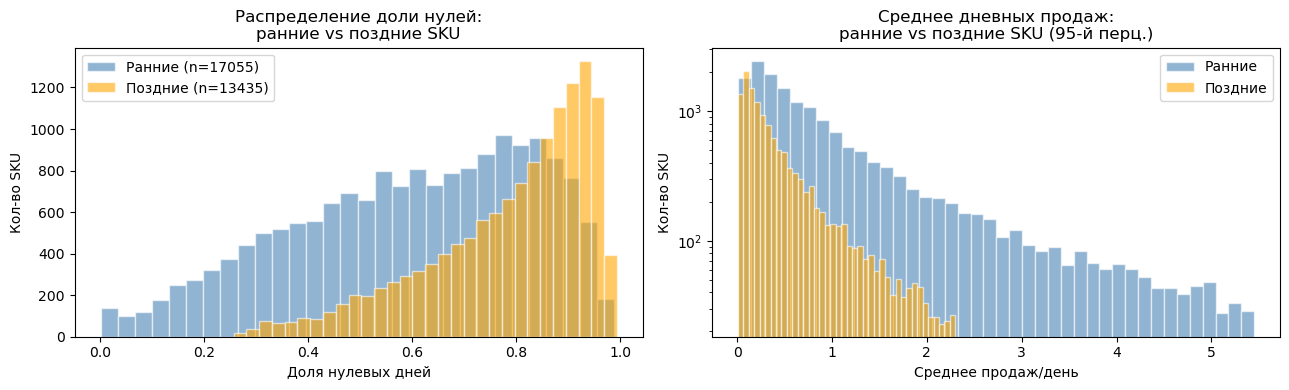

Mann-Whitney доля нулей (ранние vs поздние): p=0.0000
Mann-Whitney среднее продаж (ранние vs поздние): p=0.0000


In [23]:
# Делим SKU на "ранние" (first_day < 365) и "поздние" (first_day >= 365)
early_mask = sku_activity["first_day"] < 365
late_mask  = sku_activity["first_day"] >= 365

early_idx = sku_activity[early_mask].index
late_idx  = sku_activity[late_mask].index

print(f"Ранние SKU (first_day < 365):  {early_mask.sum()} ({early_mask.mean():.1%})")
print(f"Поздние SKU (first_day >= 365): {late_mask.sum()} ({late_mask.mean():.1%})\n")

# Сравниваем ключевые метрики
for label, idx in [("Ранние", early_idx), ("Поздние", late_idx)]:
    m = sales_matrix.loc[idx]
    zeros = (m == 0).mean(axis=1)
    nonzero_vals = m.values[m.values > 0]
    print(f"{label}:")
    print(f"  Доля нулей (медиана по SKU): {zeros.median():.1%}")
    print(f"  Среднее дневных продаж:      {m.mean().mean():.2f}")
    print(f"  Медиана ненулевых продаж:    {np.median(nonzero_vals):.1f}")
    print(f"  Ultra-sparse (>90% нулей):   {(zeros > 0.9).mean():.1%}\n")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Доля нулей
zeros_early = (sales_matrix.loc[early_idx] == 0).mean(axis=1)
zeros_late  = (sales_matrix.loc[late_idx]  == 0).mean(axis=1)

axes[0].hist(zeros_early, bins=30, alpha=0.6, color="steelblue",
             edgecolor="white", label=f"Ранние (n={early_mask.sum()})")
axes[0].hist(zeros_late,  bins=30, alpha=0.6, color="orange",
             edgecolor="white", label=f"Поздние (n={late_mask.sum()})")
axes[0].set_title("Распределение доли нулей:\nранние vs поздние SKU")
axes[0].set_xlabel("Доля нулевых дней")
axes[0].set_ylabel("Кол-во SKU")
axes[0].legend()

# Среднее дневных продаж
mean_early = sales_matrix.loc[early_idx].mean(axis=1)
mean_late  = sales_matrix.loc[late_idx].mean(axis=1)

axes[1].hist(mean_early[mean_early < mean_early.quantile(0.95)],
             bins=40, alpha=0.6, color="steelblue",
             edgecolor="white", label="Ранние")
axes[1].hist(mean_late[mean_late < mean_late.quantile(0.95)],
             bins=40, alpha=0.6, color="orange",
             edgecolor="white", label="Поздние")
axes[1].set_title("Среднее дневных продаж:\nранние vs поздние SKU (95-й перц.)")
axes[1].set_xlabel("Среднее продаж/день")
axes[1].set_ylabel("Кол-во SKU")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

# Статтест
stat, p = stats.mannwhitneyu(zeros_early, zeros_late, alternative="two-sided")
print(f"Mann-Whitney доля нулей (ранние vs поздние): p={p:.4f}")
stat, p = stats.mannwhitneyu(mean_early, mean_late, alternative="two-sided")
print(f"Mann-Whitney среднее продаж (ранние vs поздние): p={p:.4f}")

## Вывод: ранние vs поздние SKU

| Метрика | Ранние (first_day < 365) | Поздние (first_day ≥ 365) |
|---|---|---|
| Кол-во SKU | 17 055 (55.9%) | 13 435 (44.1%) |
| Медиана доли нулей | 62.3% | 83.1% |
| Среднее продаж/день | 1.51 | 0.65 |
| Ultra-sparse (>90% нулей) | 7.3% | 29.0% |
| Медиана ненулевых продаж | 2.0 | 2.0 |

Mann-Whitney: оба теста p<0.001 — различия статистически значимы.

**Ключевой вывод:** поздние SKU систематически разреженнее и
слабее по объёму — не потому что они "хуже", а потому что у них
меньше времени накопить историю. Медиана ненулевых продаж
одинакова (2.0) — когда поздний SKU продаётся, он продаётся
столько же, сколько ранний.

**Это важно для маски активности:**
Исключение предисторических нулей (до первой продажи) — корректно
и не вносит bias. Поздние SKU просто имеют более короткую историю,
а не другой паттерн спроса. Модель должна учитывать
`age_of_series` (дней с первой продажи) как признак — он объясняет
большую часть разницы между группами.

**Cold start стратегия:**
Для поздних SKU с историей < 28 дней прогноз строится на уровне
агрегата (dept_id × store_id), а не индивидуального SKU.

In [24]:
import gc

# ============================================================
# 1. WIDE → LONG + MERGE
# ============================================================
print("1. Wide → Long...")
sales_long_final = (
    sales_train[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"] + d_cols]
    .melt(
        id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
        var_name="d", value_name="sales"
    )
)

print("   Merge calendar...")
sales_long_final = sales_long_final.merge(
    calendar[["d", "date", "wm_yr_wk", "weekday", "wday", "month", "year",
              "event_name_1", "event_type_1", "event_name_2", "event_type_2",
              "snap_CA", "snap_TX", "snap_WI"]],
    on="d", how="left"
)

print("   Merge prices...")
sales_long_final = sales_long_final.merge(
    sell_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left"
)

sales_long_final["date"] = pd.to_datetime(sales_long_final["date"])
sales_long_final = sales_long_final.sort_values(["id", "date"]).reset_index(drop=True)
print(f"   Shape после merge: {sales_long_final.shape}")

# ============================================================
# 2. МАСКА АКТИВНОСТИ
# ============================================================
print("2. Маска активности...")
first_sale_day = (sales_train[d_cols] > 0).idxmax(axis=1)
first_sale_map = (sales_train[["id"]]
                  .assign(first_sale_d=first_sale_day)
                  .set_index("id")["first_sale_d"])

sales_long_final["first_sale_d"] = sales_long_final["id"].map(first_sale_map)
sales_long_final = sales_long_final[
    sales_long_final["d"] >= sales_long_final["first_sale_d"]
].reset_index(drop=True)
print(f"   Shape после маски: {sales_long_final.shape}")

# ============================================================
# 3. ПРИЗНАКИ ИЗ КАЛЕНДАРЯ И СЕЗОННОСТИ
# ============================================================
print("3. Календарные признаки...")

# Недельная / годовая сезонность
sales_long_final["is_weekend"]    = sales_long_final["wday"].isin([1, 7]).astype(np.int8)
sales_long_final["week_of_year"]  = sales_long_final["date"].dt.isocalendar().week.astype(int)
sales_long_final["day_of_year"]   = sales_long_final["date"].dt.dayofyear

# Праздники
top_events = {"LaborDay", "SuperBowl", "Easter", "OrthodoxEaster"}
sales_long_final["has_event"]    = sales_long_final["event_name_1"].notna().astype(np.int8)
sales_long_final["is_top_event"] = sales_long_final["event_name_1"].isin(top_events).astype(np.int8)
sales_long_final["event_name_1"] = sales_long_final["event_name_1"].fillna("none")
sales_long_final["event_type_1"] = sales_long_final["event_type_1"].fillna("none")
sales_long_final["event_name_2"] = sales_long_final["event_name_2"].fillna("none")

# SNAP — отдельно по штатам (не агрегировать!)
sales_long_final["snap_CA"] = sales_long_final["snap_CA"].astype(np.int8)
sales_long_final["snap_TX"] = sales_long_final["snap_TX"].astype(np.int8)
sales_long_final["snap_WI"] = sales_long_final["snap_WI"].astype(np.int8)

# ============================================================
# 4. ПРИЗНАКИ ИЗ ЦЕН
# ============================================================
print("4. Ценовые признаки...")

sales_long_final["price_roll_mean_28"] = (
    sales_long_final.groupby("id")["sell_price"]
    .transform(lambda x: x.rolling(28, min_periods=1).mean())
)
sales_long_final["price_rel"]  = (
    sales_long_final["sell_price"] / sales_long_final["price_roll_mean_28"]
)
sales_long_final["is_promo"]   = (sales_long_final["price_rel"] < 0.9).astype(np.int8)
sales_long_final["price_change"] = (
    sales_long_final.groupby("id")["sell_price"].diff().fillna(0)
)

# ============================================================
# 5. ЛАГОВЫЕ ПРИЗНАКИ (ACF/PACF: лаги 1,2,7,14,28,56)
# ============================================================
print("5. Лаговые признаки...")
for lag in [1, 2, 7, 14, 28, 56]:
    sales_long_final[f"lag_{lag}"] = (
        sales_long_final.groupby("id")["sales"]
        .transform(lambda x: x.shift(lag))
    )
    print(f"   lag_{lag} готов")

# ============================================================
# 6. СКОЛЬЗЯЩИЕ СРЕДНИЕ И СТД
# ============================================================
print("6. Rolling признаки...")
for window in [7, 28, 56]:
    sales_long_final[f"roll_mean_{window}"] = (
        sales_long_final.groupby("id")["sales"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    sales_long_final[f"roll_std_{window}"] = (
        sales_long_final.groupby("id")["sales"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )
    print(f"   roll_{window} готов")

# ============================================================
# 7. ПРИЗНАКИ АКТИВНОСТИ SKU
# ============================================================
print("7. Признаки активности...")
d_num_map = {d: i for i, d in enumerate(d_cols)}
sales_long_final["d_num"]         = sales_long_final["d"].map(d_num_map)
sales_long_final["first_sale_num"] = sales_long_final["first_sale_d"].map(d_num_map)
sales_long_final["age_of_series"]  = (
    sales_long_final["d_num"] - sales_long_final["first_sale_num"]
)
sales_long_final["is_new_sku"]     = (
    sales_long_final["age_of_series"] < 28
).astype(np.int8)

# ============================================================
# 8. ФЛАГ ВЫБРОСА (только активные SKU, IQR-метод)
# ============================================================
print("8. Флаг выброса...")
sku_q3  = sales_long_final.groupby("id")["sales"].transform("quantile", 0.75)
sku_q1  = sales_long_final.groupby("id")["sales"].transform("quantile", 0.25)
sku_iqr = sku_q3 - sku_q1
sku_mean = sales_long_final.groupby("id")["sales"].transform("mean")

# Флаг только для активных SKU (mean > 1), для остальных = 0
sales_long_final["is_outlier_day"] = np.where(
    sku_mean > 1,
    (sales_long_final["sales"] > sku_q3 + 3 * sku_iqr).astype(np.int8),
    np.int8(0)
)

# ============================================================
# 9. TRAIN / VAL SPLIT
# ============================================================
print("9. Split...")
sales_long_final["split"] = pd.cut(
    sales_long_final["d_num"],
    bins=[-1, val1_start - 1, val2_start - 1, len(d_cols)],
    labels=["train", "val1", "val2"]
)

# ============================================================
# 10. ФИНАЛЬНАЯ ЧИСТКА
# ============================================================
print("10. Финальная чистка...")
drop_cols = ["first_sale_d", "first_sale_num", "wm_yr_wk"]
sales_long_final = sales_long_final.drop(columns=drop_cols)

# Оптимизация памяти
for col in ["wday", "month", "year", "week_of_year", "day_of_year", "d_num"]:
    sales_long_final[col] = sales_long_final[col].astype(np.int16)
sales_long_final["sales"] = sales_long_final["sales"].astype(np.int32)

gc.collect()

# ============================================================
# 11. ИТОГ
# ============================================================
print(f"\n{'='*50}")
print(f"Финальный датасет: {sales_long_final.shape}")
print(f"\nКолонки ({len(sales_long_final.columns)}):")
for col in sales_long_final.columns:
    print(f"  {col}: {sales_long_final[col].dtype}")

print(f"\nРаспределение по split:")
print(sales_long_final["split"].value_counts().sort_index())

print(f"\nПропуски (топ-10):")
nulls = sales_long_final.isnull().sum()
print(nulls[nulls > 0].head(10))

print(f"\nПамять: {sales_long_final.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

# Сохраняем
print("\nСохранение...")
sales_long_final.to_csv("m5_dataset_final.csv", index=False)
print("Готово: m5_dataset_final.csv")

1. Wide → Long...
   Merge calendar...
   Merge prices...
   Shape после merge: (59181090, 22)
2. Маска активности...
   Shape после маски: (33202011, 23)
3. Календарные признаки...
4. Ценовые признаки...
5. Лаговые признаки...
   lag_1 готов
   lag_2 готов
   lag_7 готов
   lag_14 готов
   lag_28 готов
   lag_56 готов
6. Rolling признаки...
   roll_7 готов
   roll_28 готов
   roll_56 готов
7. Признаки активности...
8. Флаг выброса...
9. Split...
10. Финальная чистка...

Финальный датасет: (33202011, 47)

Колонки (47):
  id: object
  item_id: object
  dept_id: object
  cat_id: object
  store_id: object
  state_id: object
  d: object
  sales: int32
  date: datetime64[ns]
  weekday: object
  wday: int16
  month: int16
  year: int16
  event_name_1: object
  event_type_1: object
  event_name_2: object
  event_type_2: object
  snap_CA: int8
  snap_TX: int8
  snap_WI: int8
  sell_price: float64
  is_weekend: int8
  week_of_year: int16
  day_of_year: int16
  has_event: int8
  is_top_event: in

In [ ]:
# Правильный способ загрузки
import pandas as pd

# Только первые строки — проверить что всё ок
df = pd.read_csv("m5_dataset_final.csv", nrows=5)
print(df)

# Полная загрузка — нужно ~28 GB RAM
df = pd.read_csv("m5_dataset_final.csv")

                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
1  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
2  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
3  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
4  FOODS_1_001_CA_1_evaluation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   

     d  sales        date    weekday  ...  roll_std_7  roll_mean_28  \
0  d_1      3  2011-01-29   Saturday  ...    0.000000           NaN   
1  d_2      0  2011-01-30     Sunday  ...    0.000000           3.0   
2  d_3      0  2011-01-31     Monday  ...    2.121320           1.5   
3  d_4      1  2011-02-01    Tuesday  ...    1.732051           1.0   
4  d_5      4  2011-02-02  Wednesday  ...    1.414214           1.0   

   roll_std_28 roll_mean_56 roll_std_56 d_num  age_of_series  is_new_sku  \
0     0.00